# MODELIZACIÓN CLASIFICACIÓN PROBABILITY OF DEFAULT

## IMPORTAR PAQUETES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.model_selection import GridSearchCV

from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.metrics import RocCurveDisplay
import scikitplot as skplt

#Autocompletar rápido
%config IPCompleter.greedy=True

#Desactivar la notación científica
pd.options.display.float_format = '{:.2f}'.format

#Desactivar los warnings
import warnings
warnings.filterwarnings("ignore")

## IMPORTAR LOS DATOS

Sustituir la ruta del proyecto.

In [2]:
from credit_scoring.config import PROCESSED_DATA_DIR

ruta_proyecto = PROCESSED_DATA_DIR

2026-09-15 16:01:09.982 | INFO     | credit_scoring.config:<module>:11 - PROJ_ROOT path is: /home/isailzc/credit_scoring/credit_scoring


Nombres de los archivos de datos.

In [3]:
nombre = 'df_tablon_pd.pickle'

Cargar los datos.

In [4]:
df = pd.read_pickle(ruta_proyecto / nombre)

In [5]:
df.target_pd.value_counts(normalize=True)

0   0.88
1   0.12
Name: target_pd, dtype: float64

In [6]:
x = df.drop(columns='target_pd')
y = df.target_pd

## MODELIZAR

### Reservar el dataset de validacion

In [7]:
train_x,val_x,train_y,val_y = train_test_split(x,y,test_size=0.3, random_state=42)

### Crear el pipe y el diccionario de algorimos, parámetros y valores a testar

In [8]:
pipe = Pipeline([('algoritmo',LogisticRegression())])

grid = [{'algoritmo': [LogisticRegression(solver = 'saga', n_jobs=-1, random_state=42)],
         'algoritmo__penalty': ['elasticnet', 'l1', 'l2'],
         'algoritmo__C': [0,0.25,0.5,0.75,1]}
       ]

### Optimizar los hiper parámetros

####  Con grid search

In [14]:
from sklearn.model_selection import StratifiedKFold

# Definir la estrategia de CV con semilla fija
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=grid, 
    cv=cv_strategy,  
    scoring='roc_auc',
    n_jobs=-1
)
modelo = grid_search.fit(train_x,train_y)

In [15]:
salida = pd.DataFrame(grid_search.cv_results_).sort_values(by = 'rank_test_score').reset_index(drop=True).head(5)
salida

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_algoritmo,param_algoritmo__C,param_algoritmo__penalty,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,4.87,0.89,0.04,0.01,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",1,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.69,0.71,0.69,0.70,0.70,0.70,0.00,1
1,5.02,0.61,0.05,0.02,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.75,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.69,0.71,0.69,0.70,0.70,0.70,0.00,2
2,13.36,1.10,0.03,0.01,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",1,l2,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.69,0.71,0.69,0.70,0.70,0.70,0.00,3
3,12.89,2.30,0.04,0.02,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.75,l2,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.69,0.71,0.69,0.70,0.70,0.70,0.00,4
4,4.69,0.55,0.05,0.02,"LogisticRegression(C=1, n_jobs=-1, penalty='l1...",0.50,l1,"{'algoritmo': LogisticRegression(C=1, n_jobs=-...",0.69,0.71,0.69,0.70,0.70,0.70,0.00,5


Vemos que el resultados del auc es el mismo en todas las primeras configuraciones.

Y reentreamos el modelo con esa configuración.

In [18]:
# Instanciar 
rl = LogisticRegression(solver='saga', n_jobs=-1, C=1, penalty='l1', random_state=42)
rl.fit(train_x, train_y)

#Entrenar
rl.fit(train_x,train_y)

LogisticRegression(C=1, n_jobs=-1, penalty='l1', random_state=42, solver='saga')

Podemos revisar los coefecientes para ver los que son cero y las variables más importantes.

In [19]:
coeficientes = pd.DataFrame(data = rl.coef_, columns = rl.feature_names_in_).stack().droplevel(level = 0).sort_values()
coeficientes

tipo_interes_mms                       -2.44
principal_mms                          -1.15
ingresos_mms                           -1.12
ingresos_verificados_Not Verified      -0.28
num_cuotas_ 36 months                  -0.19
finalidad_vacation                     -0.18
finalidad_house                        -0.14
finalidad_other                        -0.12
finalidad_car                          -0.08
antigüedad_empleo_oe_mms               -0.08
vivienda_MORTGAGE                      -0.05
finalidad_credit_card                  -0.04
finalidad_otros                        -0.03
vivienda_OWN                            0.00
dti_mms                                 0.00
ingresos_verificados_Source Verified    0.00
finalidad_medical                       0.00
num_cuotas_ 60 months                   0.01
finalidad_debt_consolidation            0.03
finalidad_major_purchase                0.08
ingresos_verificados_Verified           0.09
finalidad_home_improvement              0.10
finalidad_

## EVALUAR

### Predecir sobre validación

In [20]:
pred = rl.predict_proba(val_x)[:, 1]

### Evaluar sobre validación

In [21]:
roc_auc_score(val_y, pred)

0.7015187164729837

## REPORTING DEL MODELO

In [22]:
from credit_scoring.config import PROJ_ROOT

### Gain Chart

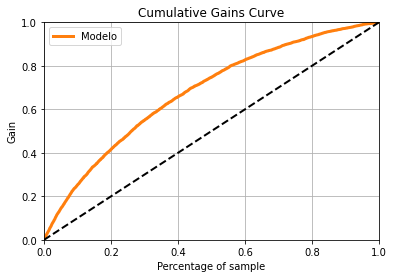

In [23]:
figure_path = PROJ_ROOT / 'reports' / 'figures' / 'cumulative_gain.png'

fig, ax = plt.subplots()

skplt.metrics.plot_cumulative_gain(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros
lines = ax.get_lines()
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda
plt.legend(labels=['Modelo'])

# 2. Guardar la figura en alta resolución antes de mostrarla
fig.savefig(figure_path, dpi=300, bbox_inches='tight')

plt.show()

### Lift Chart

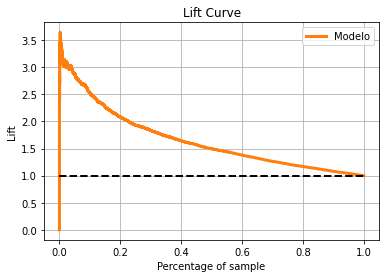

In [24]:
figure_path = PROJ_ROOT / 'reports' / 'figures' / 'lift_curve.png'

fig, ax = plt.subplots()

skplt.metrics.plot_lift_curve(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax) 

# Eliminamos la línea de los ceros
lines = ax.get_lines()
for line in lines:
    if line.get_label() == 'Class 0':
        line.remove()

# Personalizamos la leyenda
plt.legend(labels=['Modelo'])

# Guardar la gráfica en alta calidad antes de renderizarla
fig.savefig(figure_path, dpi=300, bbox_inches='tight')

plt.show()

### ROC Chart

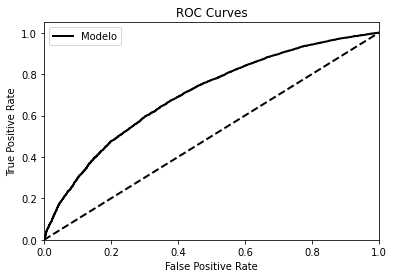

In [25]:
figure_path = PROJ_ROOT / 'reports' / 'figures' / 'roc_curve.png'

fig, ax = plt.subplots()

# Generamos la gráfica ROC
skplt.metrics.plot_roc(val_y, modelo.best_estimator_.predict_proba(val_x), ax=ax)

# Obtenemos todas las líneas y las leyendas
lines = ax.get_lines()

# Recorremos las líneas para eliminar las no deseadas, excepto la línea de la clase 0
for line in lines:
    if 'ROC curve of class 0' in line.get_label():
        line.set_label('Modelo')
    elif line.get_linestyle() != '--':  # Mantenemos la línea punteada pero sin leyenda
        line.set_visible(False)

# Solo añadimos al leyenda la línea de la clase 0 renombrada a 'Modelo'
handles, labels = ax.get_legend_handles_labels()
new_handles = [h for h, l in zip(handles, labels) if l == 'Modelo']
new_labels = ['Modelo']

ax.legend(new_handles, new_labels, loc='best')

# Guardar la gráfica en alta calidad antes de renderizarla
fig.savefig(figure_path, dpi=300, bbox_inches='tight')

# Ahora puedes mostrar el gráfico
plt.show();